# 📱 Telecom Customer Churn Analysis using Python

## Business Problem

Customer churn is one of the biggest challenges for telecom companies because acquiring new customers is significantly more expensive than retaining existing ones.

The objective of this project is to identify the major factors influencing customer churn through exploratory data analysis and provide actionable recommendations that can help improve customer retention.

---

## Project Objectives

- Understand customer churn patterns
- Identify high-risk customer groups
- Analyze factors influencing churn
- Generate business insights
- Recommend strategies to reduce churn

---

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab





In [49]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in the current directory:")
print(os.listdir())


Current Working Directory:
/content

Files in the current directory:
['.config', 'telecom_data_dictionary.csv', 'telecom_zipcode_population.csv', 'telecom_customer_churn.csv', 'sample_data']


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

In [6]:
dictionary = pd.read_csv("telecom_data_dictionary.csv", encoding="cp1252")

In [7]:
customer = pd.read_csv("telecom_customer_churn.csv")
zipcode = pd.read_csv("telecom_zipcode_population.csv")

In [8]:
customer.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [9]:
zipcode.head()

,Zip Code,Population
0,90001,54492
1,90002,44586
2,90003,58198
3,90004,67852
4,90005,43019


In [10]:
customer.shape

(7043, 38)

In [11]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [13]:
customer.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [15]:
# Check missing values
customer.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


In [17]:
customer.duplicated().sum()

np.int64(0)

In [18]:
# Create a copy of the dataset
df = customer.copy()

In [19]:
df["Customer Status"].value_counts()

,count
Customer Status,
Stayed,4720
Churned,1869
Joined,454


/tmp/ipykernel_1464/3033927811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


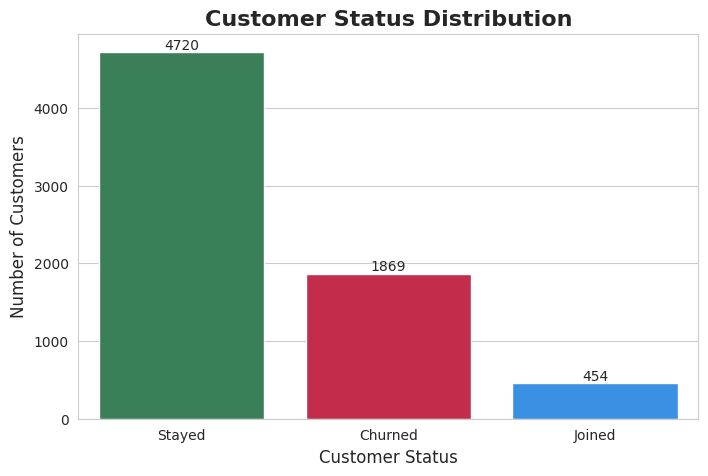

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Customer Status",
    order=["Stayed", "Churned", "Joined"],
    palette=["#2E8B57", "#DC143C", "#1E90FF"]
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Status Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Customer Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()

In [22]:
pd.crosstab(df["Contract"], df["Customer Status"])

Customer Status,Churned,Joined,Stayed
Contract,,,
Month-to-Month,1655,408,1547
One Year,166,24,1360
Two Year,48,22,1813


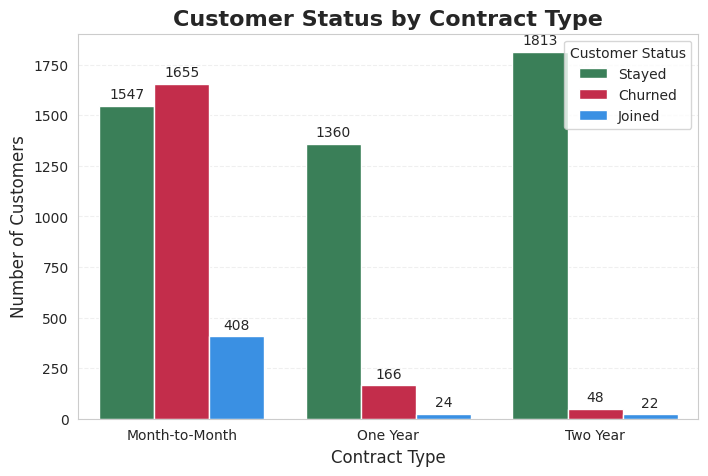

In [29]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Customer Status",
    order=["Month-to-Month", "One Year", "Two Year"],
    hue_order=["Stayed", "Churned", "Joined"],
    palette={
        "Stayed": "#2E8B57",      # Green
        "Churned": "#DC143C",     # Red
        "Joined": "#1E90FF"       # Blue
    }
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=10)

plt.title("Customer Status by Contract Type", fontsize=16, fontweight="bold")
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [24]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=internet_summary.reset_index(),
    x="Internet Type",
    y="Churned",
    color="#DC143C",
    order=internet_summary.index.tolist()
)

for i, row in internet_summary.reset_index().iterrows():
    ax.text(
        i,
        row["Churned"] + 20,
        f'{int(row["Churned"])}({row["Churn %"]}%)',
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Customer Churn by Internet Type",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Internet Type", fontsize=12)
plt.ylabel("Number of Churned Customers", fontsize=12)

plt.ylim(0, internet_summary["Churned"].max() + 250)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

Customer Status,Churned,Joined,Stayed
Contract,,,
Month-to-Month,45.8,11.3,42.9
One Year,10.7,1.5,87.7
Two Year,2.5,1.2,96.3


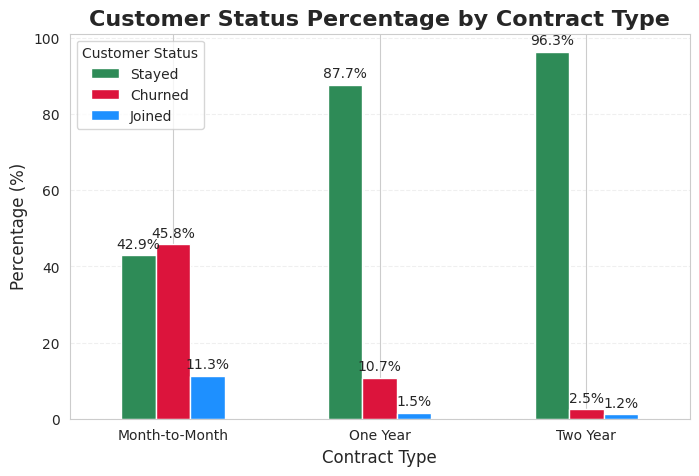

In [30]:
contract_churn = (
    pd.crosstab(df["Contract"], df["Customer Status"], normalize="index") * 100
).round(1)

ax = contract_churn[
    ["Stayed", "Churned", "Joined"]
].plot(
    kind="bar",
    figsize=(8,5),
    color=["#2E8B57", "#DC143C", "#1E90FF"]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.title("Customer Status Percentage by Contract Type", fontsize=16, fontweight="bold")
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(title="Customer Status")

plt.show()

In [31]:
# Calculate churn count and percentage
contract_summary = pd.crosstab(df["Contract"], df["Customer Status"])

contract_summary["Total"] = contract_summary.sum(axis=1)

contract_summary["Churn %"] = (
    contract_summary["Churned"] / contract_summary["Total"] * 100
).round(1)

contract_summary

Customer Status,Churned,Joined,Stayed,Total,Churn %
Contract,,,,,
Month-to-Month,1655,408,1547,3610,45.8
One Year,166,24,1360,1550,10.7
Two Year,48,22,1813,1883,2.5


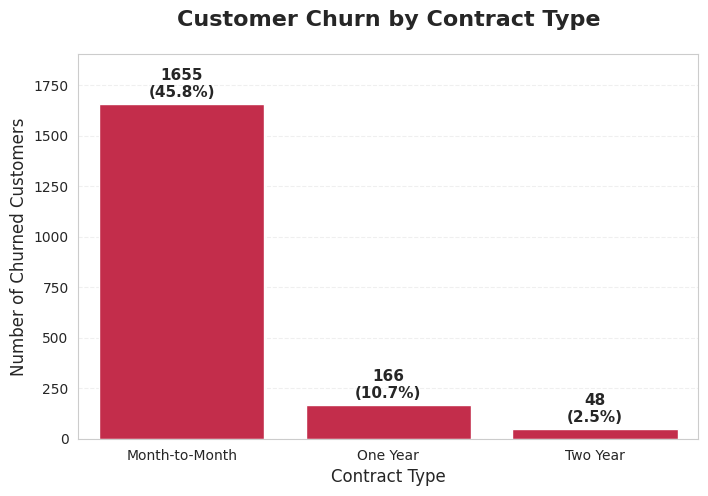

In [33]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=contract_summary.reset_index(),
    x="Contract",
    y="Churned",
    color="#DC143C",
    order=["Month-to-Month", "One Year", "Two Year"]
)

for i, row in contract_summary.reset_index().iterrows():
    ax.text(
        i,
        row["Churned"] + 20,
        f'{int(row["Churned"])}\n({row["Churn %"]}%)',
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Customer Churn by Contract Type",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Churned Customers", fontsize=12)

plt.ylim(0, contract_summary["Churned"].max() + 250)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [34]:
internet_summary = pd.crosstab(
    df["Internet Type"],
    df["Customer Status"]
)

internet_summary["Total"] = internet_summary.sum(axis=1)

internet_summary["Churn %"] = (
    internet_summary["Churned"] /
    internet_summary["Total"] * 100
).round(1)

internet_summary

Customer Status,Churned,Joined,Stayed,Total,Churn %
Internet Type,,,,,
Cable,213,56,561,830,25.7
DSL,307,115,1230,1652,18.6
Fiber Optic,1236,101,1698,3035,40.7


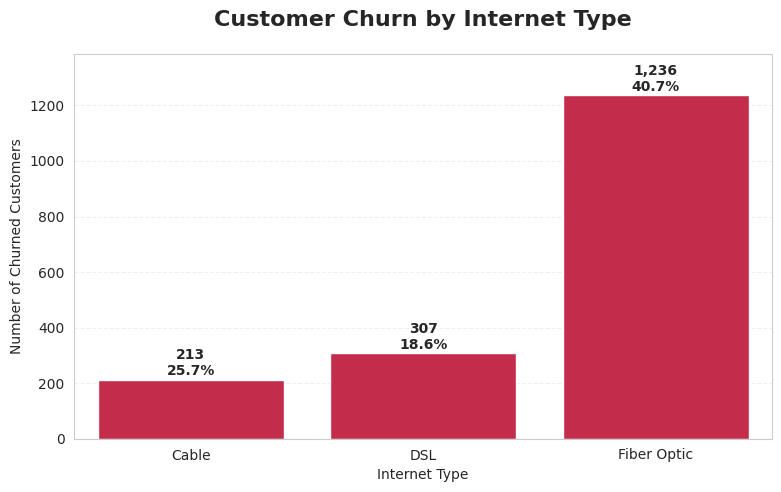

In [37]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=internet_summary.reset_index(),
    x="Internet Type",
    y="Churned",
    color="#DC143C"
)

for i, row in internet_summary.reset_index().iterrows():
    ax.text(
        i,
        row["Churned"] + 15,
        f'{row["Churned"]:,}\n{row["Churn %"]}%',
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Customer Churn by Internet Type",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Internet Type")
plt.ylabel("Number of Churned Customers")

plt.ylim(0, internet_summary["Churned"].max() + 150)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_1464/2654970642.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


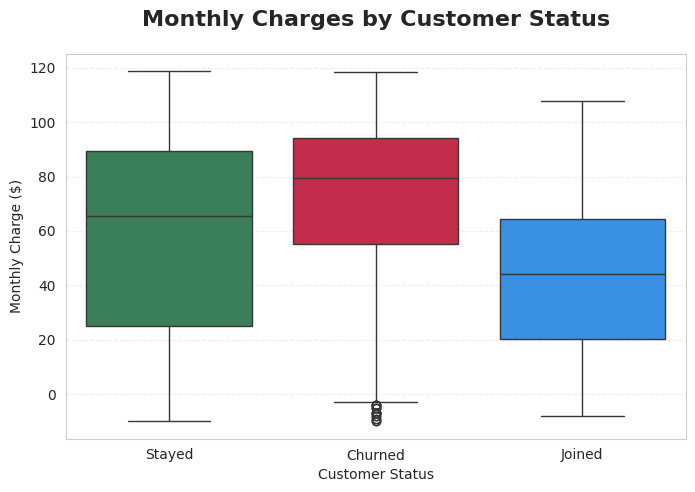

In [38]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df,
    x="Customer Status",
    y="Monthly Charge",
    order=["Stayed", "Churned", "Joined"],
    palette={
        "Stayed": "#2E8B57",
        "Churned": "#DC143C",
        "Joined": "#1E90FF"
    }
)

plt.title(
    "Monthly Charges by Customer Status",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Customer Status")
plt.ylabel("Monthly Charge ($)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [39]:
df.groupby("Customer Status")["Monthly Charge"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Customer Status,,,,,,,,
Churned,1869.0,73.35,26.37,-10.0,55.30,79.50,94.20,118.35
Joined,454.0,42.78,24.61,-8.0,20.16,43.98,64.35,107.95
Stayed,4720.0,61.74,32.20,-10.0,25.10,65.60,89.55,118.75


/tmp/ipykernel_1464/1189262482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


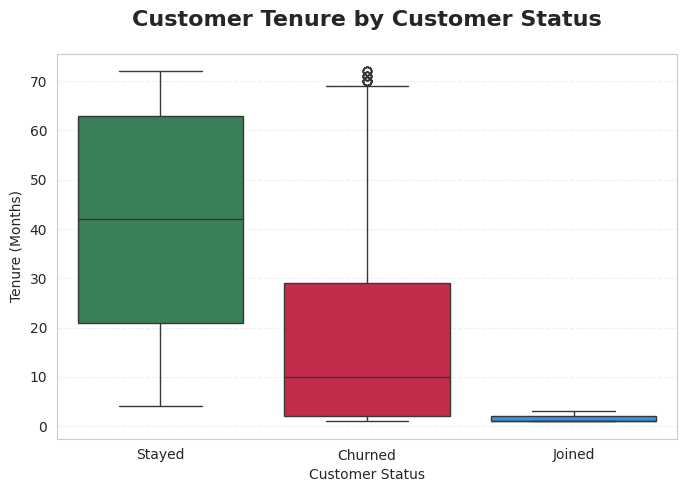

In [40]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df,
    x="Customer Status",
    y="Tenure in Months",
    order=["Stayed", "Churned", "Joined"],
    palette={
        "Stayed": "#2E8B57",
        "Churned": "#DC143C",
        "Joined": "#1E90FF"
    }
)

plt.title(
    "Customer Tenure by Customer Status",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [41]:
df.groupby("Customer Status")["Tenure in Months"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Customer Status,,,,,,,,
Churned,1869.0,18.0,19.5,1.0,2.0,10.0,29.0,72.0
Joined,454.0,1.7,0.8,1.0,1.0,1.0,2.0,3.0
Stayed,4720.0,41.0,22.4,4.0,21.0,42.0,63.0,72.0


In [43]:
df["Churn Category"].value_counts()

,count
Churn Category,
Competitor,841
Dissatisfaction,321
Attitude,314
Price,211
Other,182


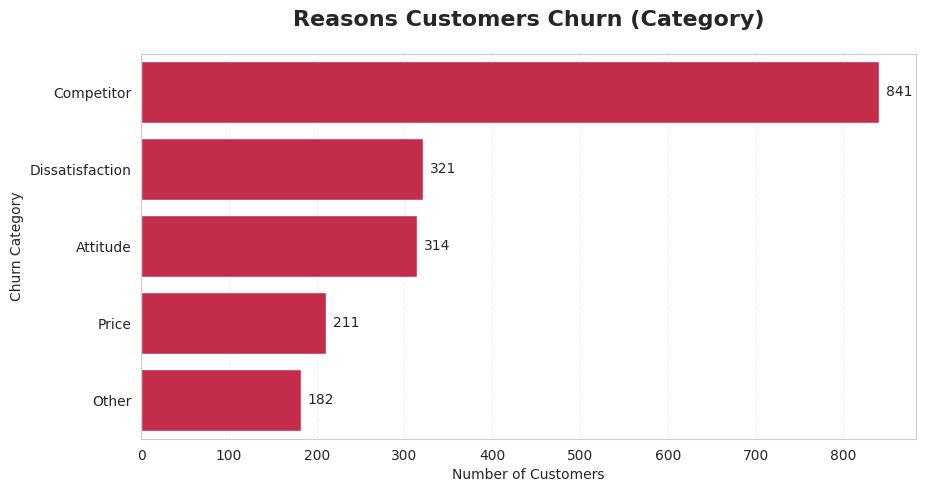

In [44]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    y="Churn Category",
    order=df["Churn Category"].value_counts().index,
    color="#DC143C"
)

# Add values
for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.title(
    "Reasons Customers Churn (Category)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Number of Customers")
plt.ylabel("Churn Category")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

In [46]:
df["Churn Reason"].value_counts()

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


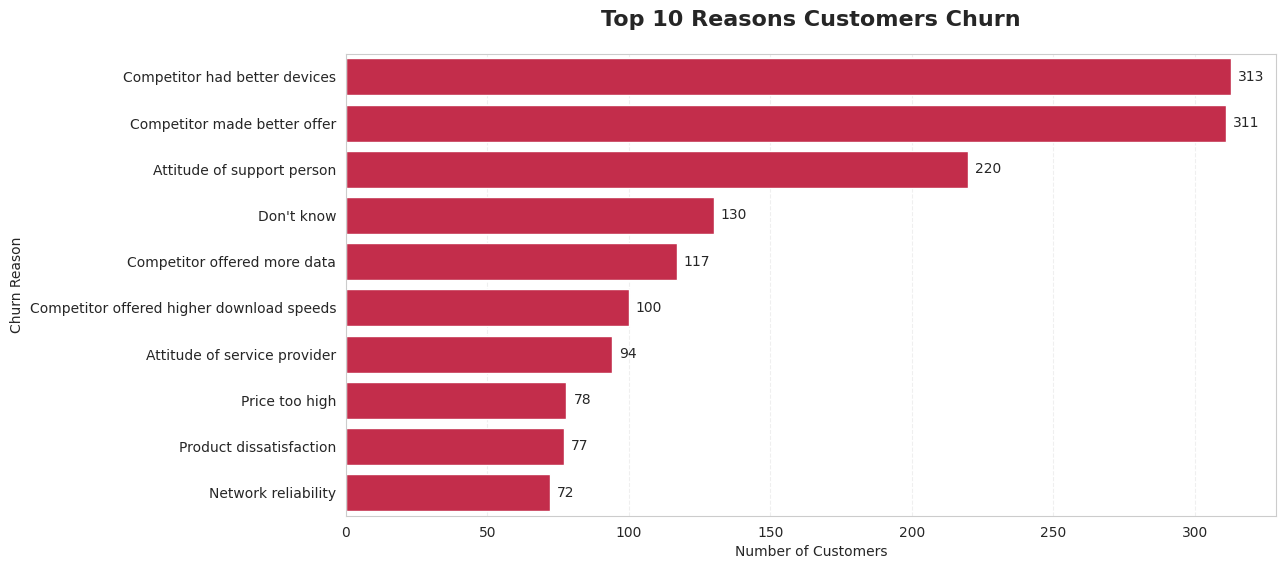

In [47]:
# Top 10 churn reasons
top_reasons = df["Churn Reason"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_reasons.values,
    y=top_reasons.index,
    color="#DC143C"
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.title(
    "Top 10 Reasons Customers Churn",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

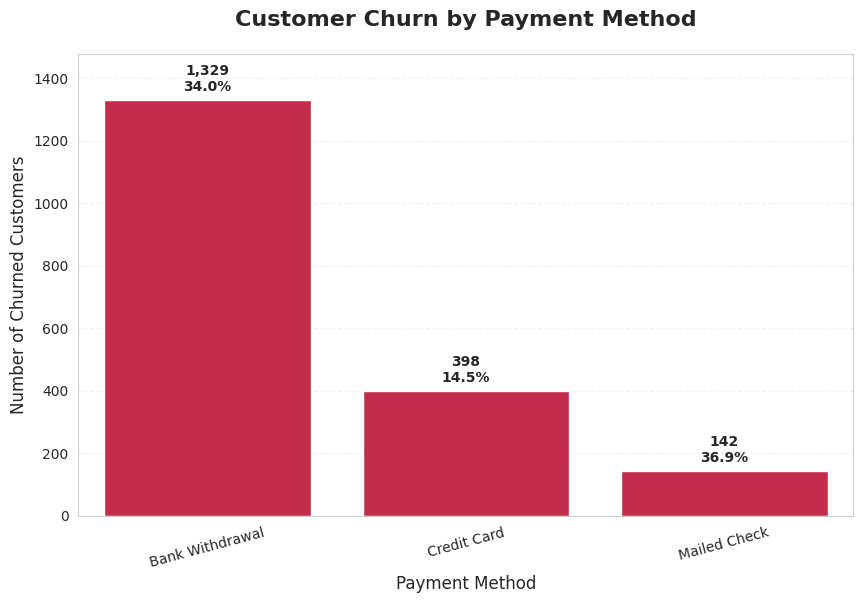

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_summary.reset_index(),
    x="Payment Method",
    y="Churned",
    color="#DC143C"
)

# Add count and percentage labels
for i, row in payment_summary.reset_index().iterrows():
    ax.text(
        i,
        row["Churned"] + 20,
        f'{row["Churned"]:,}\n{row["Churn %"]}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Customer Churn by Payment Method",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Churned Customers", fontsize=12)

plt.xticks(rotation=15)

plt.ylim(0, payment_summary["Churned"].max() + 150)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

# 📊 Key Findings

### 1. Customer Churn
- Out of 7,043 customers, 1,869 customers churned, representing approximately 27% of the customer base.

### 2. Contract Type
- Customers with Month-to-Month contracts showed the highest churn rate (45.8%).
- Customers with Two-Year contracts had the lowest churn rate (2.5%).

### 3. Internet Service
- Fiber Optic customers experienced the highest number of churned customers, indicating potential service quality or pricing concerns.

### 4. Monthly Charges
- Churned customers generally paid higher monthly charges compared to customers who stayed.

### 5. Customer Tenure
- Customers who churned had a median tenure of only 10 months, while retained customers had a median tenure of 42 months.
- Early-stage customers are therefore more likely to leave.

### 6. Churn Reasons
- The most common churn reasons were competitor offers, better devices, pricing, and dissatisfaction with service quality.

### 7. Payment Method
- Customers using the payment method with the highest churn percentage may require targeted retention strategies.


#  Business Recommendations

Based on the analysis, the telecom company should consider the following actions:

1. Encourage customers to move from Month-to-Month contracts to One-Year or Two-Year plans using discounts and loyalty rewards.

2. Strengthen customer engagement during the first year through onboarding campaigns and proactive customer support.

3. Review pricing strategies for customers paying higher monthly charges to ensure better value.

4. Improve the quality and reliability of Fiber Optic services where churn is highest.

5. Monitor competitor offerings and improve pricing, bundled services, and device promotions.

6. Investigate payment methods associated with higher churn and encourage customers to switch to more stable payment options.


# Conclusion

This analysis explored the major factors influencing customer churn within a telecom company.

The results indicate that contract type, monthly charges, customer tenure, internet service type, payment method, and competitor-related factors all have a significant relationship with customer churn.

The findings suggest that focusing on early customer retention, promoting long-term contracts, improving service quality, and offering competitive pricing could substantially reduce customer churn and improve long-term customer retention.

This project demonstrates how exploratory data analysis can transform raw customer data into actionable business insights that support strategic decision-making.